In [4]:
# Import required libraries and packages
import sys
sys.path.insert(1, "/mnt/c/Users/PC/Desktop/wikolego-repository/ai-path/ml-next-step/src")

import matplotlib.pyplot as plt
import pandas as pd
import tensorflow as tf

import config

print(tf.__version__)

2.10.0


In [5]:
# Load MNIST data
df = pd.read_csv(config.NEW_DATA_PATH)
df = df.drop(columns=["id"])

# initialize training data
df_train = df.loc[df["kfold"] != 1, :]
df_test = df.loc[df["kfold"] == 1, :]

df_train = df_train.drop(columns=["kfold"])
df_test = df_test.drop(columns=["kfold"])

Epoch 1/200
1/1 [==============================] - 1s 713ms/step - loss: 87.2627 - sparse_categorical_accuracy: 0.1176 - val_loss: 103.1668 - val_sparse_categorical_accuracy: 0.1625
Epoch 2/200
1/1 [==============================] - 0s 232ms/step - loss: 102.9178 - sparse_categorical_accuracy: 0.1539 - val_loss: 88.9664 - val_sparse_categorical_accuracy: 0.3085
Epoch 3/200
1/1 [==============================] - 0s 174ms/step - loss: 87.3728 - sparse_categorical_accuracy: 0.3040 - val_loss: 82.5517 - val_sparse_categorical_accuracy: 0.4280
Epoch 4/200
1/1 [==============================] - 0s 224ms/step - loss: 81.0730 - sparse_categorical_accuracy: 0.4166 - val_loss: 69.1490 - val_sparse_categorical_accuracy: 0.4540
Epoch 5/200
1/1 [==============================] - 0s 179ms/step - loss: 68.2751 - sparse_categorical_accuracy: 0.4416 - val_loss: 49.1280 - val_sparse_categorical_accuracy: 0.4510
Epoch 6/200
1/1 [==============================] - 0s 177ms/step - loss: 48.8282 - sparse_cat

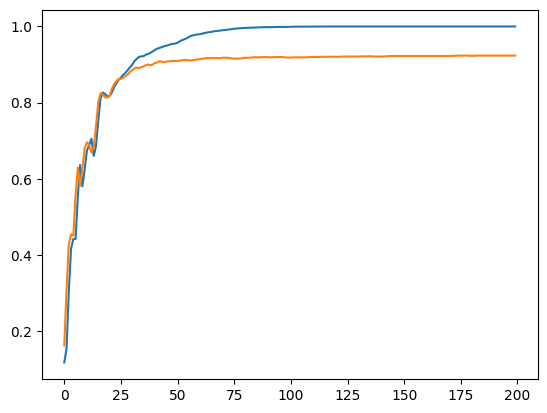

In [8]:
model = tf.keras.models.Sequential([
    tf.keras.layers.Dense(512, activation="relu", input_shape=(28*28, )), # input layer
    # tf.keras.layers.Dropout(0.125),
    tf.keras.layers.Dense(512, activation="relu"),
    # tf.keras.layers.Dropout(0.125),
    tf.keras.layers.Dense(512, activation="relu"),
    # tf.keras.layers.Dropout(0.125),
    tf.keras.layers.Dense(10, activation="softmax") # output layer
])

# Compile model
model.compile(
    optimizer="Adam",
    loss="SparseCategoricalCrossentropy",
    metrics=["SparseCategoricalAccuracy"]
)

# Fit model
result = model.fit(
    df_train.drop(columns=["label"]).values,
    df_train.loc[:, "label"].values,
    batch_size=8000,
    epochs=200,
    validation_data=(df_test.drop(columns=["label"]).values, df_test.loc[:, "label"].values),
)

# Predict and print predictions
predictions = max(result.history["sparse_categorical_accuracy"])
print(predictions)

if True:
    plt.plot(result.history["sparse_categorical_accuracy"])
    plt.plot(result.history["val_sparse_categorical_accuracy"])
    plt.show()

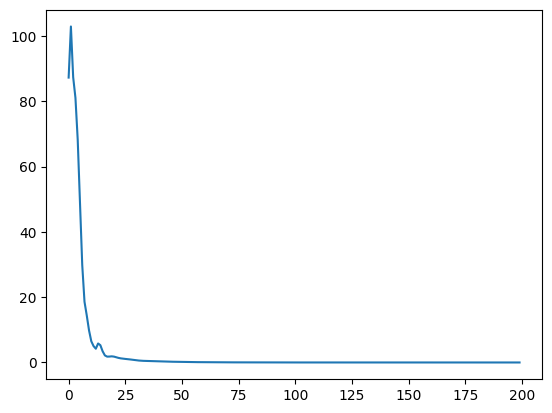

In [9]:
plt.plot(result.history["loss"])
plt.show()